# Level 1 – Task 2: Data Cleaning and Preprocessing
**Dataset:** Telecom Customer Churn (churn-bigml-80.csv)
**Goal:** Clean the raw dataset so it's ready for machine learning models.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Load the dataset
df = pd.read_csv('../churn-bigml-80.csv')
print("Shape:", df.shape)
df.head()


Shape: (2666, 20)


,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


## 1. Basic Overview

In [2]:
# Quick look at data types and non-null counts
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [3]:
# Summary statistics for numerical columns
df.describe()


,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


## 2. Handling Missing Values

In [4]:
# Check how many missing values each column has
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "No missing values found!")


Missing values per column:
No missing values found!


In [5]:
# If there were missing values, we'd handle them like this:
# For numerical columns – fill with median (robust to outliers)
# df['col'] = df['col'].fillna(df['col'].median())

# For categorical columns – fill with mode (most common value)
# df['col'] = df['col'].fillna(df['col'].mode()[0])

# Our dataset looks clean, but let's double-check
print("Total missing values:", df.isnull().sum().sum())


Total missing values: 0


## 3. Removing Duplicates

In [6]:
before = len(df)
df = df.drop_duplicates()
after = len(df)
print(f"Removed {before - after} duplicate rows. Rows remaining: {after}")


Removed 0 duplicate rows. Rows remaining: 2666


## 4. Detecting and Removing Outliers

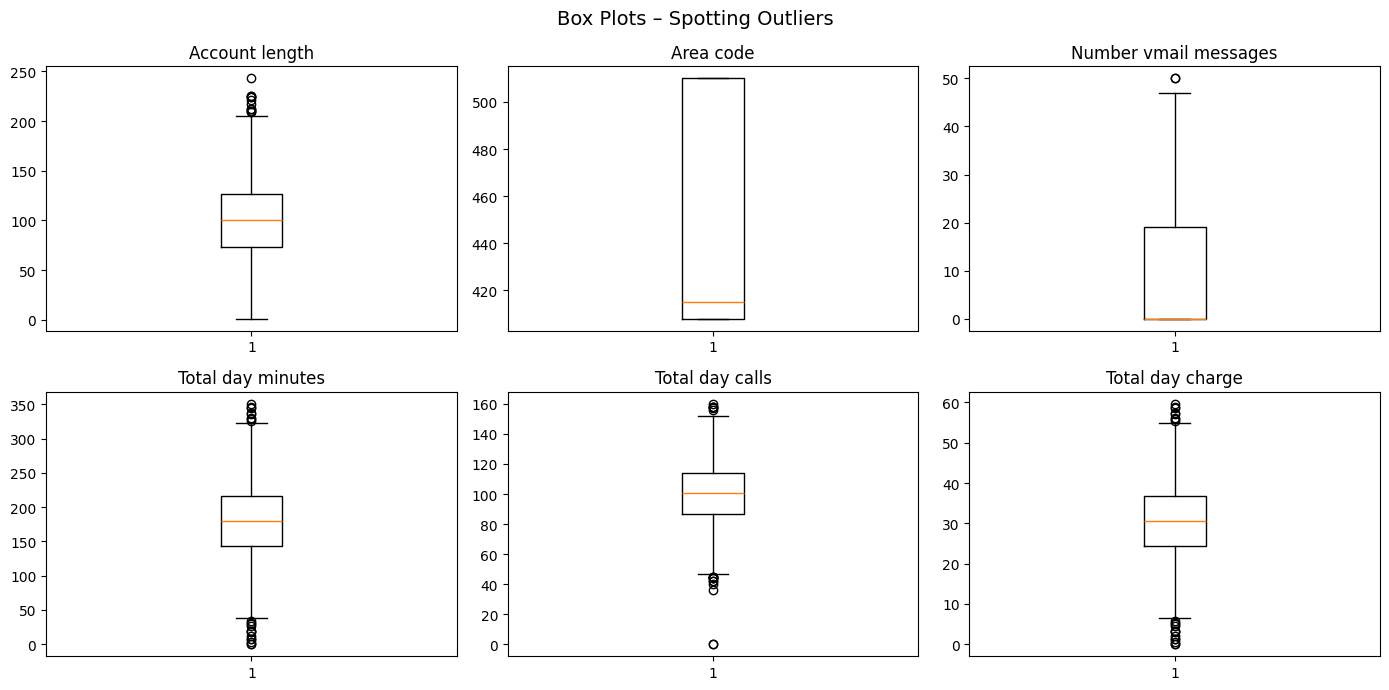

In [7]:
# Use IQR method on numerical columns
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
axes = axes.flatten()

for i, col in enumerate(numeric_cols[:6]):
    axes[i].boxplot(df[col].dropna())
    axes[i].set_title(col)

plt.suptitle("Box Plots – Spotting Outliers", fontsize=14)
plt.tight_layout()
plt.show()


In [8]:
# Remove outliers using IQR for key columns
def remove_outliers_iqr(data, col):
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    return data[(data[col] >= lower) & (data[col] <= upper)]

cols_to_clean = ['Total day minutes', 'Total day charge', 'Customer service calls']
df_clean = df.copy()

for col in cols_to_clean:
    before = len(df_clean)
    df_clean = remove_outliers_iqr(df_clean, col)
    print(f"{col}: removed {before - len(df_clean)} outliers")

print("Final shape after outlier removal:", df_clean.shape)


Total day minutes: removed 21 outliers
Total day charge: removed 0 outliers
Customer service calls: removed 209 outliers
Final shape after outlier removal: (2436, 20)


## 5. Encoding Categorical Variables

In [9]:
# Check which columns are categorical (object type)
cat_cols = df_clean.select_dtypes(include='object').columns.tolist()
print("Categorical columns:", cat_cols)


Categorical columns: ['State', 'International plan', 'Voice mail plan']


In [10]:
# Label encode binary columns (Yes/No, True/False)
le = LabelEncoder()

binary_cols = ['International plan', 'Voice mail plan', 'Churn']
for col in binary_cols:
    df_clean[col] = le.fit_transform(df_clean[col].astype(str))
    print(f"Encoded '{col}'")

# One-hot encode 'State' (many categories)
df_clean = pd.get_dummies(df_clean, columns=['State'], drop_first=True)
print("After encoding, shape:", df_clean.shape)
df_clean.head(3)


Encoded 'International plan'
Encoded 'Voice mail plan'
Encoded 'Churn'
After encoding, shape: (2436, 69)


,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,...,State_SD,State_TN,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY
0,128,415,0,1,25,265.1,110,45.07,197.4,99,...,False,False,False,False,False,False,False,False,False,False
1,107,415,0,1,26,161.6,123,27.47,195.5,103,...,False,False,False,False,False,False,False,False,False,False
2,137,415,0,0,0,243.4,114,41.38,121.2,110,...,False,False,False,False,False,False,False,False,False,False


## 6. Normalizing Numerical Features

In [11]:
# StandardScaler: mean=0, std=1  –  good for most ML models
scaler = StandardScaler()

num_cols = ['Account length', 'Total day minutes', 'Total day calls',
            'Total day charge', 'Total eve minutes', 'Total intl calls']

df_clean[num_cols] = scaler.fit_transform(df_clean[num_cols])
print("Normalized columns:")
df_clean[num_cols].describe().round(2)


Normalized columns:


,Account length,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total intl calls
count,2436.00,2436.00,2436.00,2436.00,2436.00,2436.00
mean,0.00,-0.00,-0.00,0.00,-0.00,0.00
std,1.00,1.00,1.00,1.00,1.00,1.00
min,-2.50,-2.71,-3.06,-2.71,-3.92,-1.82
25%,-0.69,-0.69,-0.67,-0.69,-0.68,-0.60
50%,-0.02,0.01,-0.01,0.01,0.01,-0.20
75%,0.69,0.68,0.65,0.68,0.68,0.61
max,3.57,2.71,3.03,2.71,3.01,6.29


## 7. Save the Clean Dataset

In [12]:
df_clean.to_csv('../churn_cleaned.csv', index=False)
print("Clean dataset saved as 'churn_cleaned.csv'")
print("Final shape:", df_clean.shape)


Clean dataset saved as 'churn_cleaned.csv'
Final shape: (2436, 69)


## Summary
- Checked for missing values → dataset was already clean
- Removed duplicate rows
- Detected outliers with IQR and removed them from key columns
- Encoded categorical columns (label encoding + one-hot encoding)
- Normalized numerical features with StandardScaler
- Saved the cleaned dataset for use in downstream tasks
